# Proyecto de Minería de Datos
## Modelo de Clasificación con Regresión Logística

**Problema:** predicción del resultado de partidos de fútbol.

**Variable objetivo:** `resultado_real`

- `S` = victoria del equipo local
- `H` = empate
- `A` = victoria del equipo visitante

Este notebook trabaja sobre los datos existentes del proyecto y **no sobrescribe los archivos CSV**.


## 1. Definición del problema y variable objetivo

El objetivo es construir un modelo de **Regresión Logística multiclase** capaz de clasificar el resultado de un partido de fútbol en una de tres categorías: victoria local (`S`), empate (`H`) o victoria visitante (`A`).

Se seleccionó `resultado_real` como variable dependiente porque representa directamente el desenlace que se desea predecir.

Las variables independientes fueron seleccionadas porque contienen información previa o disponible al momento de realizar la predicción: votos de participantes, porcentajes de apuesta, clasificación de los equipos, puntos, partidos jugados, goles, diferencia de goles, cuotas y día de la semana.

Se excluyen como variables de entrada `Results_1`, `Results_2`, `resultado_real`, `prediccion_personas` y `acierto_personas`, porque contienen el resultado final o información derivada directamente de él y producirían **fuga de información (data leakage)**.


In [58]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score,
)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## 2. Carga del dataset

El notebook busca automáticamente la raíz del repositorio `Grupo_Patitogit`, por lo que puede ejecutarse desde la raíz o desde `Codigo/Notebooks/`.


In [59]:
def encontrar_raiz_proyecto():
    actual = Path.cwd().resolve()

    for carpeta in [actual, *actual.parents]:
        if (carpeta / "Data").exists() and (carpeta / "Codigo").exists():
            return carpeta

    raise FileNotFoundError(
        "No se encontró la raíz del proyecto. "
        "Ejecuta el notebook dentro de Grupo_Patitogit."
    )

RAIZ = encontrar_raiz_proyecto()

RUTA_DATOS = (
    RAIZ
    / "Data"
    / "raw"
    / "predicciones_personas.csv"
)

print("Raíz del proyecto:", RAIZ)
print("Dataset:", RUTA_DATOS)

if not RUTA_DATOS.exists():
    raise FileNotFoundError(f"No existe el archivo: {RUTA_DATOS}")

datos = pd.read_csv(RUTA_DATOS)

print("Dataset cargado correctamente.")
print("Filas:", len(datos))
print("Columnas:", len(datos.columns))


Raíz del proyecto: /home/fabian/Grupo_Patitogit
Dataset: /home/fabian/Grupo_Patitogit/Data/raw/predicciones_personas.csv


Dataset cargado correctamente.
Filas: 11417
Columnas: 65


In [60]:
datos.head()


,Votes_for_Home,Votes_for_Draw,Votes_for_Away,Weekday,Day,Month,Year,Hour,Minute,Total_Bettors,...,Country_2,Detail_H2H,Indices_home,Indices_draw,Indices_away,Results_1,Results_2,resultado_real,prediccion_personas,acierto_personas
0,18,14,19,Thu,3,1,2019,21,0,64512,...,england,3/A/D/0/0_6/H/L/1/2_9/H/L/1/2_10/A/L/0/3_12/A/...,9_10_13_19_21_52_44_46_24_77_82_87_88_89_90_10...,6_14_50_51_25_38_43_78_85_86_92_93_94_104,11_12_15_16_27_30_35_37_39_54_81_84_96_99_102_...,2,1,S,A,False
1,3,1,45,Wed,2,1,2019,21,0,25872,...,england,3/A/L/2/3_11/H/W/1/0_14/A/L/1/4_37/H/D/3/3_41/...,21_42_44,104,48_6_9_10_11_12_14_15_16_19_51_52_53_26_27_28_...,0,2,A,A,True
2,5,1,42,Sat,12,1,2019,16,0,22624,...,england,5/A/L/0/1_9/A/L/0/4_14/H/L/1/5_84/A/L/1/6_90/H...,13_14_21_42_100,93,3_6_8_9_10_11_12_15_16_50_18_51_52_29_30_35_36...,0,1,A,A,True
3,46,0,1,Sat,19,1,2019,16,0,22400,...,england,6/A/L/2/3_9/A/L/0/1_11/H/W/2/0_15/H/W/1/0,2_3_6_9_10_11_12_13_14_16_50_18_19_21_52_26_27...,NaN,36,2,1,S,S,True
4,44,0,3,Sat,12,1,2019,18,30,16576,...,england,5/A/W/2/1_9/A/L/0/3_12/H/W/3/0_14/H/W/3/1_36/H...,6_8_10_11_12_14_15_16_50_18_51_21_52_27_29_35_...,NaN,30_77_100,2,1,S,S,True


## 3. Revisión inicial

Se revisa la variable objetivo, su distribución y la existencia de valores faltantes antes del modelado.


In [61]:
VARIABLE_OBJETIVO = "resultado_real"

if VARIABLE_OBJETIVO not in datos.columns:
    raise ValueError(
        f"No existe la variable objetivo '{VARIABLE_OBJETIVO}' en el dataset."
    )

print("Distribución de la variable objetivo:")
print(datos[VARIABLE_OBJETIVO].value_counts(dropna=False))

print("\nPorcentajes:")
print(
    datos[VARIABLE_OBJETIVO]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)


Distribución de la variable objetivo:
resultado_real
S    5316
A    3491
H    2610
Name: count, dtype: int64

Porcentajes:
resultado_real
S    46.56
A    30.58
H    22.86
Name: proportion, dtype: float64


In [62]:
faltantes = datos.isna().sum().sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]

resumen_faltantes = pd.DataFrame({
    "faltantes": faltantes,
    "porcentaje": (faltantes / len(datos) * 100).round(2)
})

resumen_faltantes.head(20)


,faltantes,porcentaje
Indices_draw,8581,75.16
Jumps,5686,49.80
Win_Perc_2,5686,49.80
Detail_H2H,5686,49.80
Number_of_H2H_matches,5686,49.80
Draw_Perc_2,5686,49.80
Avrage_FT_Goal,5686,49.80
Won_out_of_6,5686,49.80
Average_HT_Goal,5686,49.80
Team_2_Found,5686,49.80


## 4. Variables independientes

Se emplean variables numéricas relacionadas con las predicciones de los participantes y el rendimiento de los equipos. `Weekday` se tratará como categórica para aplicar `OneHotEncoder`.


In [63]:
variables_numericas = [
    "Votes_for_Home",
    "Votes_for_Draw",
    "Votes_for_Away",
    "Total_Bettors",
    "Bet_Perc_on_Home",
    "Bet_Perc_on_Draw",
    "Bet_Perc_on_Away",
    "League_Rank_1",
    "League_Rank_2",
    "Games_played_1",
    "Games_played_2",
    "Points_1",
    "Points_2",
    "Goals_Scored_1",
    "Goals_Scored_2",
    "Goals_Rec_1",
    "Goal_Rec_2",
    "Goals_Diff_1",
    "Goals_Diff_2",
    "Odds_Home",
    "Odds_Draw",
    "Odds_Away",
]

variables_categoricas = [
    "Weekday",
]

variables_prohibidas = {
    "Results_1",
    "Results_2",
    "resultado_real",
    "prediccion_personas",
    "acierto_personas",
}

assert not variables_prohibidas.intersection(
    variables_numericas + variables_categoricas
), "Se detectó una variable que provoca fuga de información."

variables_solicitadas = variables_numericas + variables_categoricas
faltan = [c for c in variables_solicitadas if c not in datos.columns]

if faltan:
    raise ValueError(
        "Faltan estas columnas en el dataset: "
        + ", ".join(faltan)
    )

print("Variables numéricas:", len(variables_numericas))
print("Variables categóricas:", len(variables_categoricas))
print("Variable objetivo:", VARIABLE_OBJETIVO)


Variables numéricas: 22
Variables categóricas: 1
Variable objetivo: resultado_real


## 5. División en entrenamiento y prueba

Se utiliza una división cronológica 80/20: el primer 80 % de los partidos se usa para entrenamiento y el último 20 % para prueba.


In [64]:
trabajo = datos.copy()
trabajo = trabajo.dropna(subset=[VARIABLE_OBJETIVO]).copy()

if {"Year", "Month", "Day"}.issubset(trabajo.columns):
    trabajo["fecha_modelo"] = pd.to_datetime(
        {
            "year": trabajo["Year"],
            "month": trabajo["Month"],
            "day": trabajo["Day"],
        },
        errors="coerce",
    )

    trabajo = trabajo.sort_values(
        by="fecha_modelo",
        na_position="last"
    ).reset_index(drop=True)

trabajo["Weekday"] = trabajo["Weekday"].astype("string")

X = trabajo[variables_numericas + variables_categoricas].copy()
y = trabajo[VARIABLE_OBJETIVO].copy()

punto_division = int(len(trabajo) * 0.80)

X_entrenamiento = X.iloc[:punto_division].copy()
X_prueba = X.iloc[punto_division:].copy()

y_entrenamiento = y.iloc[:punto_division].copy()
y_prueba = y.iloc[punto_division:].copy()

print("Total de registros:", len(trabajo))
print("Entrenamiento:", len(X_entrenamiento))
print("Prueba:", len(X_prueba))


Total de registros: 11417
Entrenamiento: 9133
Prueba: 2284


## 6. Limpieza, codificación y escalado

- Nulos numéricos: mediana.
- Nulos categóricos: valor más frecuente.
- Variables numéricas: `StandardScaler`.
- Variables categóricas: `OneHotEncoder`.
- Todo el proceso se integra dentro de un `Pipeline`.


In [65]:
pipeline_numerico = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler()),
    ]
)

pipeline_categorico = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="most_frequent")),
        (
            "codificador",
            OneHotEncoder(handle_unknown="ignore"),
        ),
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            pipeline_numerico,
            variables_numericas,
        ),
        (
            "categoricas",
            pipeline_categorico,
            variables_categoricas,
        ),
    ]
)

modelo_inicial = Pipeline(
    steps=[
        ("preprocesador", preprocesador),
        (
            "modelo",
            LogisticRegression(
                max_iter=3000,
                random_state=42,
            ),
        ),
    ]
)

print("Pipeline creado correctamente.")


Pipeline creado correctamente.


## 7. Entrenamiento del modelo inicial


In [66]:
modelo_inicial.fit(
    X_entrenamiento,
    y_entrenamiento
)

predicciones_iniciales = modelo_inicial.predict(
    X_prueba
)

probabilidades_iniciales = modelo_inicial.predict_proba(
    X_prueba
)

print("Modelo inicial entrenado correctamente.")


Modelo inicial entrenado correctamente.


## 8. Evaluación: accuracy, precision, recall y F1


In [67]:
accuracy_inicial = accuracy_score(
    y_prueba,
    predicciones_iniciales
)

precision_inicial = precision_score(
    y_prueba,
    predicciones_iniciales,
    average="macro",
    zero_division=0,
)

recall_inicial = recall_score(
    y_prueba,
    predicciones_iniciales,
    average="macro",
    zero_division=0,
)

f1_inicial = f1_score(
    y_prueba,
    predicciones_iniciales,
    average="macro",
    zero_division=0,
)

print("MODELO INICIAL")
print(f"Accuracy:  {accuracy_inicial:.4f}")
print(f"Precision: {precision_inicial:.4f}")
print(f"Recall:    {recall_inicial:.4f}")
print(f"F1 macro:  {f1_inicial:.4f}")

print("\nReporte de clasificación:")
print(
    classification_report(
        y_prueba,
        predicciones_iniciales,
        zero_division=0,
    )
)


MODELO INICIAL
Accuracy:  0.5311
Precision: 0.4860
Recall:    0.4504
F1 macro:  0.4057

Reporte de clasificación:
              precision    recall  f1-score   support

           A       0.48      0.52      0.50       677
           H       0.42      0.03      0.06       553
           S       0.56      0.80      0.66      1054

    accuracy                           0.53      2284
   macro avg       0.49      0.45      0.41      2284
weighted avg       0.50      0.53      0.47      2284



## 9. Matriz de confusión


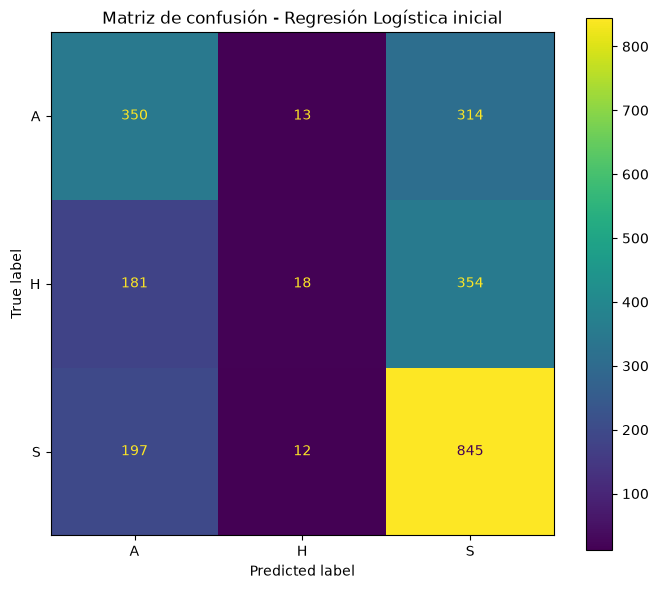

In [68]:
clases_orden = ["A", "H", "S"]

matriz = confusion_matrix(
    y_prueba,
    predicciones_iniciales,
    labels=clases_orden,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=clases_orden,
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
ax.set_title("Matriz de confusión - Regresión Logística inicial")
plt.tight_layout()
plt.show()


## 10. Curva ROC multiclase

Se utiliza el enfoque One-vs-Rest para representar una curva ROC por clase.


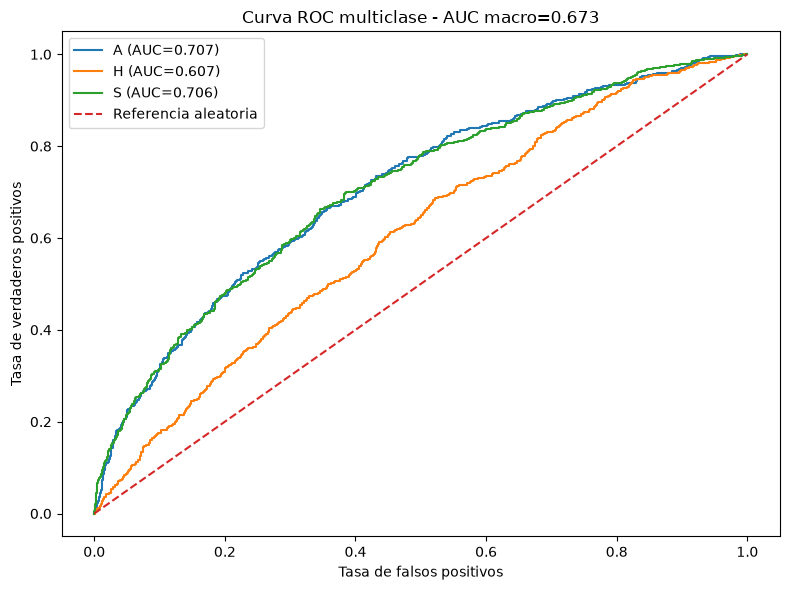

In [69]:
clases_modelo = modelo_inicial.named_steps["modelo"].classes_

y_prueba_bin = label_binarize(
    y_prueba,
    classes=clases_modelo,
)

auc_macro_inicial = roc_auc_score(
    y_prueba_bin,
    probabilidades_iniciales,
    average="macro",
    multi_class="ovr",
)

plt.figure(figsize=(8, 6))

for i, clase in enumerate(clases_modelo):
    fpr, tpr, _ = roc_curve(
        y_prueba_bin[:, i],
        probabilidades_iniciales[:, i],
    )

    auc_clase = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{clase} (AUC={auc_clase:.3f})",
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Referencia aleatoria",
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title(
    f"Curva ROC multiclase - AUC macro={auc_macro_inicial:.3f}"
)
plt.legend()
plt.tight_layout()
plt.show()


## 11. Ajuste de hiperparámetros

Se utiliza `GridSearchCV` con `TimeSeriesSplit` para evaluar distintos valores de regularización `C` y el uso de pesos balanceados.


In [70]:
parametros = {
    "modelo__C": [
        0.01,
        0.1,
        1,
        10,
        100,
    ],
    "modelo__class_weight": [
        None,
        "balanced",
    ],
}

validacion_temporal = TimeSeriesSplit(
    n_splits=5
)

busqueda = GridSearchCV(
    estimator=modelo_inicial,
    param_grid=parametros,
    scoring="f1_macro",
    cv=validacion_temporal,
    n_jobs=-1,
    refit=True,
)

busqueda.fit(
    X_entrenamiento,
    y_entrenamiento
)

print("Mejores parámetros:")
print(busqueda.best_params_)

print(
    "Mejor F1 macro de validación:",
    round(busqueda.best_score_, 4),
)


Mejores parámetros:
{'modelo__C': 0.01, 'modelo__class_weight': 'balanced'}
Mejor F1 macro de validación: 0.4782


## 12. Evaluación del modelo ajustado


In [71]:
mejor_modelo = busqueda.best_estimator_

predicciones_ajustadas = mejor_modelo.predict(
    X_prueba
)

probabilidades_ajustadas = mejor_modelo.predict_proba(
    X_prueba
)

accuracy_ajustado = accuracy_score(
    y_prueba,
    predicciones_ajustadas
)

precision_ajustado = precision_score(
    y_prueba,
    predicciones_ajustadas,
    average="macro",
    zero_division=0,
)

recall_ajustado = recall_score(
    y_prueba,
    predicciones_ajustadas,
    average="macro",
    zero_division=0,
)

f1_ajustado = f1_score(
    y_prueba,
    predicciones_ajustadas,
    average="macro",
    zero_division=0,
)

clases_ajustadas = mejor_modelo.named_steps["modelo"].classes_

y_prueba_bin_ajustada = label_binarize(
    y_prueba,
    classes=clases_ajustadas,
)

auc_macro_ajustado = roc_auc_score(
    y_prueba_bin_ajustada,
    probabilidades_ajustadas,
    average="macro",
    multi_class="ovr",
)

print("MODELO AJUSTADO")
print(f"Accuracy:  {accuracy_ajustado:.4f}")
print(f"Precision: {precision_ajustado:.4f}")
print(f"Recall:    {recall_ajustado:.4f}")
print(f"F1 macro:  {f1_ajustado:.4f}")
print(f"ROC-AUC:   {auc_macro_ajustado:.4f}")


MODELO AJUSTADO
Accuracy:  0.5039
Precision: 0.4777
Recall:    0.4785
F1 macro:  0.4776
ROC-AUC:   0.6719


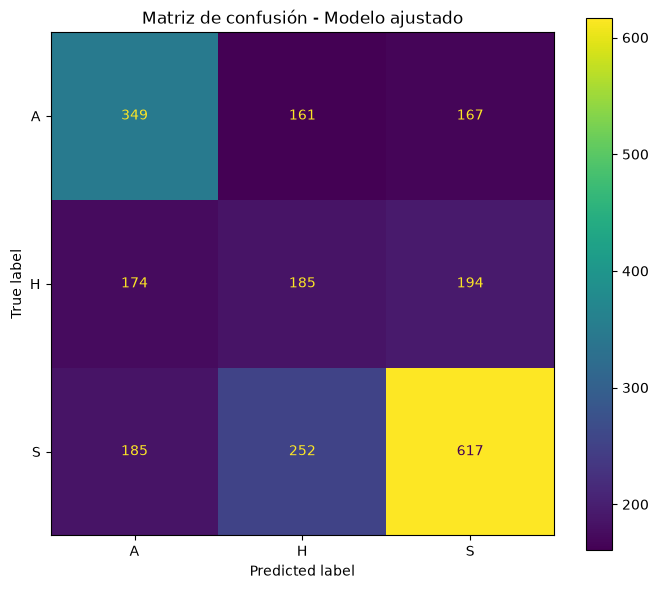

In [72]:
matriz_ajustada = confusion_matrix(
    y_prueba,
    predicciones_ajustadas,
    labels=["A", "H", "S"],
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_ajustada,
    display_labels=["A", "H", "S"],
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
ax.set_title("Matriz de confusión - Modelo ajustado")
plt.tight_layout()
plt.show()


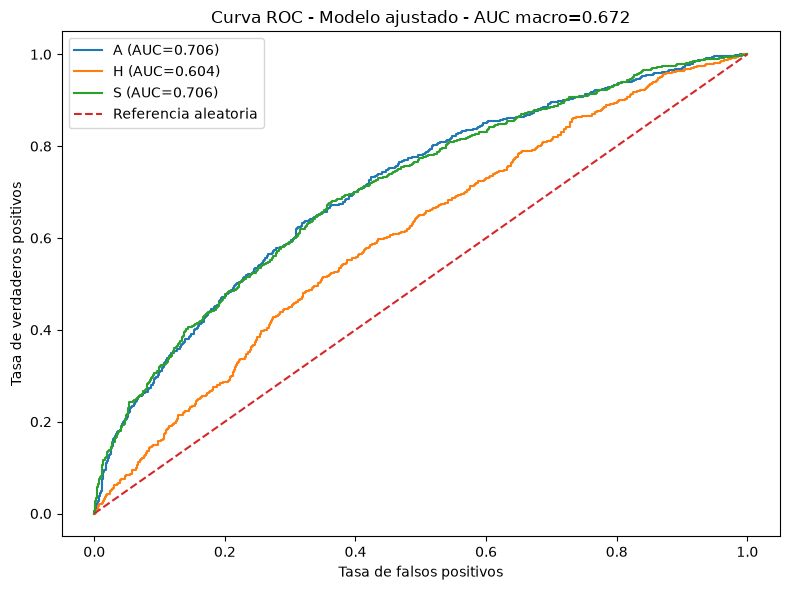

In [73]:
plt.figure(figsize=(8, 6))

for i, clase in enumerate(clases_ajustadas):
    fpr, tpr, _ = roc_curve(
        y_prueba_bin_ajustada[:, i],
        probabilidades_ajustadas[:, i],
    )

    auc_clase = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{clase} (AUC={auc_clase:.3f})",
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Referencia aleatoria",
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title(
    f"Curva ROC - Modelo ajustado - AUC macro={auc_macro_ajustado:.3f}"
)
plt.legend()
plt.tight_layout()
plt.show()


## 13. Comparación con baselines

Se compara el modelo con una estrategia de clase mayoritaria y, cuando está disponible, con la predicción mayoritaria de las personas.


In [74]:
clase_mayoritaria = y_entrenamiento.mode().iloc[0]

prediccion_mayoritaria = np.repeat(
    clase_mayoritaria,
    len(y_prueba),
)

accuracy_baseline = accuracy_score(
    y_prueba,
    prediccion_mayoritaria,
)

print(
    f"Baseline clase mayoritaria ({clase_mayoritaria}): "
    f"{accuracy_baseline:.4f}"
)

accuracy_personas = None

if "prediccion_personas" in trabajo.columns:
    pred_personas_prueba = (
        trabajo["prediccion_personas"]
        .iloc[punto_division:]
        .reset_index(drop=True)
    )

    y_prueba_personas = (
        y_prueba
        .reset_index(drop=True)
    )

    mascara = pred_personas_prueba.notna()

    if mascara.any():
        accuracy_personas = accuracy_score(
            y_prueba_personas[mascara],
            pred_personas_prueba[mascara],
        )

        print(
            "Predicción mayoritaria de personas:",
            f"{accuracy_personas:.4f}",
        )


Baseline clase mayoritaria (S): 0.4615
Predicción mayoritaria de personas: 0.5149


In [75]:
resultados = pd.DataFrame({
    "Modelo": [
        "Baseline clase mayoritaria",
        "Regresión Logística inicial",
        "Regresión Logística ajustada",
    ],
    "Accuracy": [
        accuracy_baseline,
        accuracy_inicial,
        accuracy_ajustado,
    ],
})

if accuracy_personas is not None:
    resultados.loc[len(resultados)] = [
        "Predicción mayoritaria de personas",
        accuracy_personas,
    ]

resultados["Accuracy (%)"] = (
    resultados["Accuracy"] * 100
).round(2)

resultados.sort_values(
    "Accuracy",
    ascending=False
)


,Modelo,Accuracy,Accuracy (%)
1,Regresión Logística inicial,0.531086,53.11
3,Predicción mayoritaria de personas,0.514886,51.49
2,Regresión Logística ajustada,0.503940,50.39
0,Baseline clase mayoritaria,0.461471,46.15


## 14. Interpretación de resultados

La siguiente celda genera un resumen automático con las métricas principales para facilitar la redacción de las conclusiones.


In [76]:
print("RESUMEN DEL MODELO AJUSTADO")
print("===========================")

print(
    f"El modelo obtuvo una exactitud de "
    f"{accuracy_ajustado * 100:.2f}%."
)

print(
    f"La precisión macro fue de "
    f"{precision_ajustado * 100:.2f}%."
)

print(
    f"El recall macro fue de "
    f"{recall_ajustado * 100:.2f}%."
)

print(
    f"El F1 macro fue de "
    f"{f1_ajustado * 100:.2f}%."
)

print(
    f"El ROC-AUC macro fue de "
    f"{auc_macro_ajustado:.3f}."
)

diferencia_baseline = (
    accuracy_ajustado - accuracy_baseline
) * 100

print(
    f"Frente al baseline de clase mayoritaria, "
    f"la diferencia fue de "
    f"{diferencia_baseline:+.2f} puntos porcentuales."
)

if accuracy_personas is not None:
    diferencia_personas = (
        accuracy_ajustado - accuracy_personas
    ) * 100

    print(
        f"Frente a la predicción mayoritaria de las personas, "
        f"la diferencia fue de "
        f"{diferencia_personas:+.2f} puntos porcentuales."
    )


RESUMEN DEL MODELO AJUSTADO
El modelo obtuvo una exactitud de 50.39%.
La precisión macro fue de 47.77%.
El recall macro fue de 47.85%.
El F1 macro fue de 47.76%.
El ROC-AUC macro fue de 0.672.
Frente al baseline de clase mayoritaria, la diferencia fue de +4.25 puntos porcentuales.
Frente a la predicción mayoritaria de las personas, la diferencia fue de -1.09 puntos porcentuales.


## 15. Conclusiones

Al finalizar la ejecución se deben interpretar:

- Accuracy, precision, recall y F1.
- Las clases que presentan mayor dificultad.
- La matriz de confusión.
- El AUC de las curvas ROC.
- La mejora o no obtenida mediante ajuste de hiperparámetros.
- La comparación contra el baseline y las predicciones humanas.
- Las limitaciones generadas por valores faltantes y calidad de los datos.
